In [34]:
from pyrocko import util, model, io, trace, moment_tensor, gmtpy,orthodrome
import pyrocko.moment_tensor as pmt
from pyrocko import orthodrome as od
from pyrocko.guts import load

# from seiscloud import plot as scp
# from seiscloud import cluster as scc
import numpy as np
import os
# import shutil
import matplotlib.pyplot as plt

import re
from pathlib import Path
from datetime import datetime

import yaml

# CLASS TO LOAD .YAML FILES AND READ PARAMENTER RESULTS
class IgnoreTagsLoader(yaml.SafeLoader):
    pass

def ignore_unknown(loader, tag_suffix, node):
    if isinstance(node, yaml.MappingNode):
        return loader.construct_mapping(node)
    elif isinstance(node, yaml.SequenceNode):
        return loader.construct_sequence(node)
    else:
        return loader.construct_scalar(node)

IgnoreTagsLoader.add_multi_constructor('!', ignore_unknown)

In [35]:
workdir='../' 
reportdir=os.path.join(workdir,'report')                                

plotdir=os.path.join(workdir,'PLOTS')                              
plotdir=os.path.join(plotdir,'VLP_frequency')     
plot_filename=os.path.join(plotdir,'vlp_resonant_frequency.pdf')

catdir=os.path.join(workdir,'CAT')
catname=os.path.join(catdir,'catalogue_flegrei_VLP.pf')                 # CHANGE
refevents=model.load_events(catname)
mttargets = [ev for ev in refevents]

badmtsols = ['']    # exclude some events
print(f'Catalogue: {catname}')
print('All events in catalogue:', len(mttargets))
goodmttargets = [ev for ev in mttargets if ev.name not in badmtsols]
print('Good events in catalogue:', len(goodmttargets))

# Insert inversions names
inversions= ['cmt_composite_LF_std_']                                    # CHANGE

# Insert source prefixes 
source_prefixes = ['vlp']                                             # CHANGE
par_names = ['time','north_shift','east_shift',
              'depth','magnitude',
              'rmnn','rmee','rmdd','rmne','rmnd','rmed',
              'duration','frequency',
              'strike1','dip1','rake1']

print(f'\nInversions selected: {inversions}')
print(f'Sources extracted: {source_prefixes}')

ev_stats={}

Catalogue: ../CAT/catalogue_flegrei_VLP.pf
All events in catalogue: 22
Good events in catalogue: 22

Inversions selected: ['cmt_composite_LF_std_']
Sources extracted: ['vlp']


In [36]:
#reportdir=os.path.join(workdir,'report') # pre-defined
reportdir = '/Users/giaco/UNI/PhD_CODE/GIT/Grond_composite_test_results/report'

counter_total_reports = 0
for ev in goodmttargets:
    counter = 0
    for vrs in inversions: # main report
        targetdir = os.path.join(reportdir, ev.name, vrs + ev.name)
        #if not os.path.isdir(targetdir):
            #print(ev.name, 'missing report dir', targetdir)
        if os.path.isdir(targetdir):
            counter += 1
            fname = os.path.join(targetdir, 'stats.yaml')     # results
            if os.path.isfile(fname):
                # Read file
                with open(fname, 'r') as f:
                    data = yaml.load(f, Loader=IgnoreTagsLoader)    # unsing loader class
                
                # acces 'paramenter_stats_list'
                parameter_stats = data['parameter_stats_list']
                #print(parameter_stats)
                for pref in source_prefixes:
                    ev_stats[ev.name]={pref +'.'+ par :0 for par in par_names}
                for p in parameter_stats:
                    if p['name'] in list(ev_stats[ev.name].keys()):
                        #CHANGE: choose values to extract
                        ev_stats[ev.name][p['name']]= {'best' : float( f"{p['best']:.8g}" ),   
                                                        'percentile16' : float( f"{p['percentile16']:.8g}" ),
                                                        'percentile84' : float( f"{p['percentile84']:.8g}" ),
                                                        'mean' : float( f"{p['mean']:.8g}" ),
                                                        'median' : float( f"{p['median']:.8g}" ),
                                                        'std' : float( f"{p['std']:.8g}" )
                                                        }
                        # print values
                        #print(p['name'], p['best'], p['percentile16'], p['percentile84'])

    if counter == 0:
        print(f'WARNING: {ev.name} does not have any report directories!')
    elif counter > 1:
        print(f'WARNING: {ev.name} has MULTIPLE report directories!')
    else:
        print(f'NICE! {ev.name} has report directory: {targetdir}')
        counter_total_reports += 1

print(f'\nTotal events with report directories: {counter_total_reports} out of {len(goodmttargets)}')

NICE! flegrei_2018_09_18_21_36_41 has report directory: /Users/giaco/UNI/PhD_CODE/GIT/Grond_composite_test_results/report/flegrei_2018_09_18_21_36_41/cmt_composite_LF_std_flegrei_2018_09_18_21_36_41
NICE! flegrei_2023_06_11_06_44_25 has report directory: /Users/giaco/UNI/PhD_CODE/GIT/Grond_composite_test_results/report/flegrei_2023_06_11_06_44_25/cmt_composite_LF_std_flegrei_2023_06_11_06_44_25
NICE! flegrei_2023_09_07_17_45_28 has report directory: /Users/giaco/UNI/PhD_CODE/GIT/Grond_composite_test_results/report/flegrei_2023_09_07_17_45_28/cmt_composite_LF_std_flegrei_2023_09_07_17_45_28
NICE! flegrei_2023_09_26_07_10_29 has report directory: /Users/giaco/UNI/PhD_CODE/GIT/Grond_composite_test_results/report/flegrei_2023_09_26_07_10_29/cmt_composite_LF_std_flegrei_2023_09_26_07_10_29
NICE! flegrei_2023_10_02_20_08_26 has report directory: /Users/giaco/UNI/PhD_CODE/GIT/Grond_composite_test_results/report/flegrei_2023_10_02_20_08_26/cmt_composite_LF_std_flegrei_2023_10_02_20_08_26
NICE!

In [37]:
# mean values and std
event_name=[]
freq_best=[]
freq_mean=[]
freq_median=[]
freq_err=[]

for ev_name in ev_stats:
    name=ev_name.split('_')
    name=name[1]+'-'+name[2]+'-'+name[3]
    event_name.append(name)

    freq_best.append(ev_stats[ev_name]['vlp.frequency']['best'])
    freq_mean.append(ev_stats[ev_name]['vlp.frequency']['mean'])

    f84 = ev_stats[ev_name]['vlp.frequency']['percentile84']
    f16 = ev_stats[ev_name]['vlp.frequency']['percentile16']
    f_median = (f84+f16)*0.5
    freq_median.append( f_median )
    freq_err.append( f84-f_median )
    

m_freq_mean=np.mean(freq_mean)
m_freq_median=np.mean(freq_median)

print('VLP mean frequency:\t\t',m_freq_mean,'\nVLP median frequency:\t\t',m_freq_median)

VLP mean frequency:		 0.1147805985 
VLP median frequency:		 0.11477222499999999


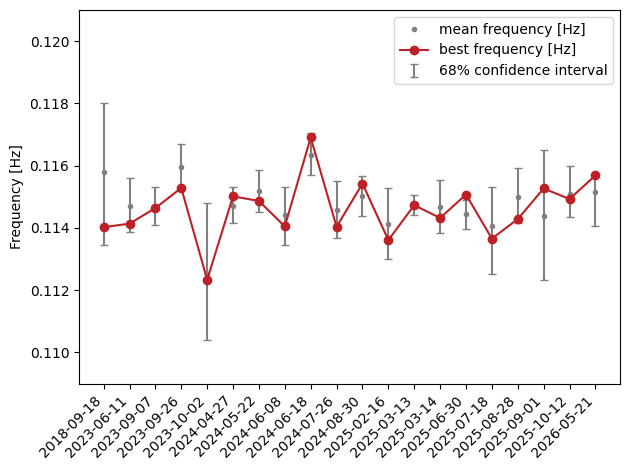

In [38]:
#plt.errorbar(event_name,freq_mean,freq_std,capsize=3,fmt='None',ecolor = "black",label='errorbar')
plt.plot(event_name,freq_mean,'.',color='gray',label='mean frequency [Hz]')
plt.errorbar(event_name,freq_median,freq_err,capsize=3,fmt='none',color='gray',ecolor = "gray",label=f'68% confidence interval')
plt.plot(event_name,freq_best,'o-',color='#BD2025',label='best frequency [Hz]')
plt.ylabel('Frequency [Hz]')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.109,0.121)
plt.legend(loc=1)
plt.tight_layout()
plt.savefig(plot_filename)


/var/folders/_5/hfq6n3xn3n53jvjz81t_f2r80000gn/T/ipykernel_37565/4254371466.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


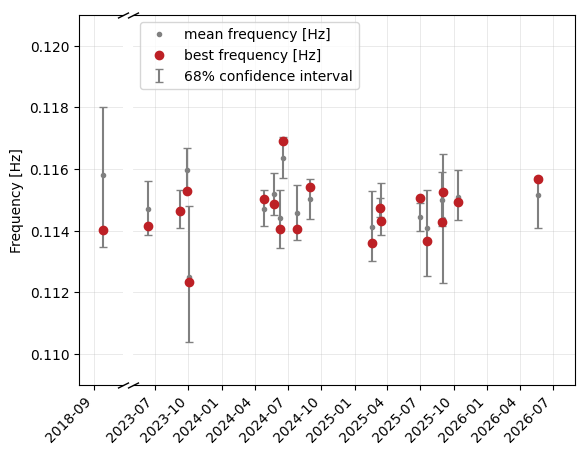

In [39]:
# same plot as above, but with a real time axis
# x-axis is broken between the 2018 event and the 2023-2026 sequence
import matplotlib.dates as mdates

plot_filename_time = os.path.join(plotdir, 'vlp_resonant_frequency_time.pdf')

# event times, same order as the freq_* lists (both built looping over ev_stats)
event_time = [datetime.strptime(ev_name.split('flegrei_')[1], '%Y_%m_%d_%H_%M_%S')
              for ev_name in ev_stats]

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True,
                               gridspec_kw={'width_ratios': [1, 10], 'wspace': 0.04})

# same three layers on both panels: what falls outside the x limits gets clipped
for ax in (ax1, ax2):
    ax.plot(event_time, freq_mean, '.', color='gray', label='mean frequency [Hz]')
    ax.errorbar(event_time, freq_median, freq_err, capsize=3, fmt='none',
                color='gray', ecolor='gray', label='68% confidence interval')
    ax.plot(event_time, freq_best, 'o', color='#BD2025', label='best frequency [Hz]')

# left panel: 2018 event only ; right panel: May 2023 -> August 2026
ax1.set_xlim(datetime(2018, 8, 1), datetime(2018, 11, 1))
ax2.set_xlim(datetime(2023, 5, 1), datetime(2026, 8, 31))

ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[9]))   # single tick on the event
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# grid, drawn behind the data
for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3, linewidth=0.6)
    ax.set_axisbelow(True)

# axis break marks
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(axis='y', left=False)
d = 0.5
kw = dict(marker=[(-1, -d), (1, d)], markersize=8, linestyle='none',
          color='k', mec='k', mew=1, clip_on=False)
ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kw)
ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kw)

ax1.set_ylabel('Frequency [Hz]')
ax1.set_ylim(0.109, 0.121)
ax2.legend(loc=2)
plt.tight_layout()
plt.savefig(plot_filename_time)
plt.show()


VLP mean magnitude:		 2.0457116899999996 
VLP median magnitude:		 2.0450934475


/var/folders/_5/hfq6n3xn3n53jvjz81t_f2r80000gn/T/ipykernel_37565/3368499693.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


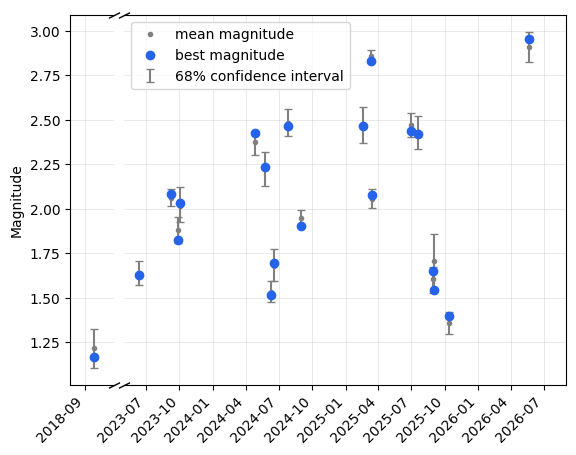

In [40]:
# same broken time axis as above, but with VLP magnitude on the y-axis
plot_filename_mag = os.path.join(plotdir, 'vlp_magnitude_time.pdf')

# magnitude values, same logic used above for the frequency
mag_best = []
mag_mean = []
mag_median = []
mag_err = []

for ev_name in ev_stats:
    mag_best.append(ev_stats[ev_name]['vlp.magnitude']['best'])
    mag_mean.append(ev_stats[ev_name]['vlp.magnitude']['mean'])

    m84 = ev_stats[ev_name]['vlp.magnitude']['percentile84']
    m16 = ev_stats[ev_name]['vlp.magnitude']['percentile16']
    m_median = (m84 + m16) * 0.5
    mag_median.append(m_median)
    mag_err.append(m84 - m_median)

print('VLP mean magnitude:\t\t', np.mean(mag_mean),
      '\nVLP median magnitude:\t\t', np.mean(mag_median))

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True,
                               gridspec_kw={'width_ratios': [1, 10], 'wspace': 0.04})

for ax in (ax1, ax2):
    ax.plot(event_time, mag_mean, '.', color='gray', label='mean magnitude')
    ax.errorbar(event_time, mag_median, mag_err, capsize=3, fmt='none',
                color='gray', ecolor='gray', label='68% confidence interval')
    ax.plot(event_time, mag_best, 'o', color='#2563EB', label='best magnitude')

# left panel: 2018 event only ; right panel: May 2023 -> August 2026
ax1.set_xlim(datetime(2018, 8, 1), datetime(2018, 11, 1))
ax2.set_xlim(datetime(2023, 5, 1), datetime(2026, 8, 31))

ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[9]))   # single tick on the event
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# grid, drawn behind the data
for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3, linewidth=0.6)
    ax.set_axisbelow(True)

# axis break marks
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(axis='y', left=False)
d = 0.5
kw = dict(marker=[(-1, -d), (1, d)], markersize=8, linestyle='none',
          color='k', mec='k', mew=1, clip_on=False)
ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kw)
ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kw)

ax1.set_ylabel('Magnitude')
ax2.legend(loc=2)
plt.tight_layout()
plt.savefig(plot_filename_mag)
plt.show()


/var/folders/_5/hfq6n3xn3n53jvjz81t_f2r80000gn/T/ipykernel_37565/2803080947.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


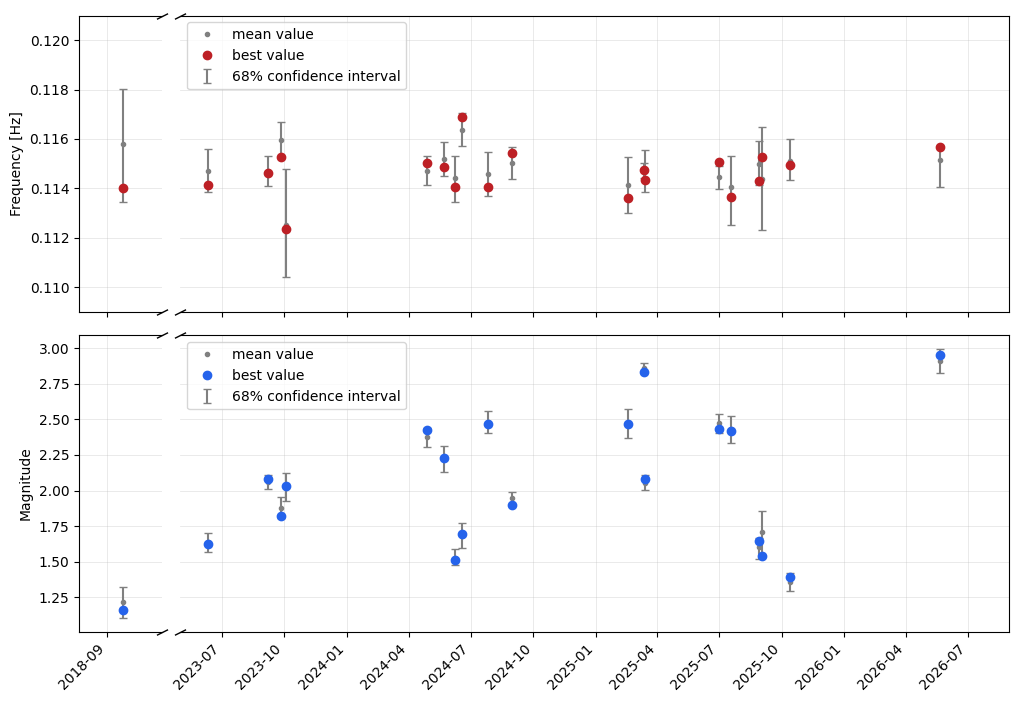

In [46]:
# the two plots above stacked: frequency on top, magnitude on the bottom
# same broken time axis, x-axes aligned (same event on the same vertical line)
plot_filename_both = os.path.join(plotdir, 'vlp_frequency_magnitude_time.pdf')

fig, axes = plt.subplots(2, 2, figsize=(12, 8),
                         sharex='col', sharey='row',
                         gridspec_kw={'width_ratios': [1, 10],
                                      'wspace': 0.04, 'hspace': 0.08})
(ax1f, ax2f), (ax1m, ax2m) = axes

# top row: frequency ; bottom row: magnitude
for ax in (ax1f, ax2f):
    ax.plot(event_time, freq_mean, '.', color='gray', label='mean value')
    ax.errorbar(event_time, freq_median, freq_err, capsize=3, fmt='none',
                color='gray', ecolor='gray', label='68% confidence interval')
    ax.plot(event_time, freq_best, 'o', color='#BD2025', label='best value')

for ax in (ax1m, ax2m):
    ax.plot(event_time, mag_mean, '.', color='gray', label='mean value')
    ax.errorbar(event_time, mag_median, mag_err, capsize=3, fmt='none',
                color='gray', ecolor='gray', label='68% confidence interval')
    ax.plot(event_time, mag_best, 'o', color='#2563EB', label='best value')

# left column: 2018 event only ; right column: May 2023 -> August 2026
for ax in (ax1f, ax1m):
    ax.set_xlim(datetime(2018, 8, 1), datetime(2018, 11, 1))
for ax in (ax2f, ax2m):
    ax.set_xlim(datetime(2023, 5, 1), datetime(2026, 8, 31))

ax1m.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[9]))   # single tick on the event
ax2m.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
for ax in (ax1m, ax2m):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# grid: horizontal to read the values, vertical on the time ticks to compare
# frequency and magnitude of the same event across the two rows
for ax in (ax1f, ax2f, ax1m, ax2m):
    ax.grid(True, alpha=0.3, linewidth=0.6)
    ax.set_axisbelow(True)

# axis break marks on both rows
d = 0.5
kw = dict(marker=[(-1, -d), (1, d)], markersize=8, linestyle='none',
          color='k', mec='k', mew=1, clip_on=False)
for ax_left, ax_right in ((ax1f, ax2f), (ax1m, ax2m)):
    ax_left.spines['right'].set_visible(False)
    ax_right.spines['left'].set_visible(False)
    ax_right.tick_params(axis='y', left=False)
    ax_left.plot([1, 1], [0, 1], transform=ax_left.transAxes, **kw)
    ax_right.plot([0, 0], [0, 1], transform=ax_right.transAxes, **kw)

ax1f.set_ylabel('Frequency [Hz]')
ax1f.set_ylim(0.109, 0.121)
ax1m.set_ylabel('Magnitude')
ax2f.legend(loc=2)
ax2m.legend(loc=2)
plt.tight_layout()
plt.savefig(plot_filename_both)
plt.show()
